In [ ]:
# Entrainement evaluation et correction d'un modèle ML baisé

## Création d'un Data set biaisé

In [11]:
import pandas as pd
import numpy as np

# Initialisation
np.random.seed(42)
n_samples = 2000

# 1. Génération des features avec des distributions réalistes
genre = np.random.choice(['Homme', 'Femme'], size=n_samples, p=[0.65, 0.35]) # Sur-représentation masculine à la candidature
age = np.random.choice(['20-30', '30-40', '40-50', '50+'], size=n_samples, p=[0.35, 0.35, 0.20, 0.10])
ville = np.random.choice(['Paris', 'Marseille', 'Lyon', 'Lille'], size=n_samples, p=[0.40, 0.25, 0.20, 0.15])
diplome = np.random.choice(['A', 'B', 'C'], size=n_samples, p=[0.25, 0.45, 0.30])

df = pd.DataFrame({
    'Genre': genre,
    'Age': age,
    'Ville': ville,
    'Diplôme': diplome
})

# 2. Définition des règles de décision avec intégration des biais
def calculer_probabilite_embauche(row):
    # Score de base
    score = 0.2
    
    # Critère légitime : Le diplôme (A est le meilleur)
    if row['Diplôme'] == 'A':
        score += 0.40
    elif row['Diplôme'] == 'B':
        score += 0.20
        
    # Biais 1 : Sur-représentation / Avantage masculin à l'embauche
    if row['Genre'] == 'Homme':
        score += 0.15
        
    # Biais 2 : Discrimination par âge (pénalise les seniors, favorise les jeunes)
    if row['Age'] == '20-30':
        score += 0.10
    elif row['Age'] == '30-40':
        score += 0.05
    elif row['Age'] == '40-50':
        score -= 0.15
    elif row['Age'] == '50+':
        score -= 0.30
        
    # Biais 3 : Avantage géographique pour Paris
    if row['Ville'] == 'Paris':
        score += 0.20
        
    # Ajout d'un bruit aléatoire pour simuler l'incertitude humaine (entretien, soft skills)
    bruit = np.random.normal(0, 0.05)
    score += bruit
    
    # Ramener la probabilité entre 0 et 1
    return np.clip(score, 0, 1)

# 3. Application des probabilités et tirage de la variable cible
probabilites = df.apply(calculer_probabilite_embauche, axis=1)
df['Embauche'] = np.random.binomial(n=1, p=probabilites)

#### Visualisation des Biais

C:\Users\boniv\AppData\Local\Temp\ipykernel_21996\492021790.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='Embauche', data=df, ax=ax, errorbar=None, palette='viridis')
C:\Users\boniv\AppData\Local\Temp\ipykernel_21996\492021790.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='Embauche', data=df, ax=ax, errorbar=None, palette='viridis')
C:\Users\boniv\AppData\Local\Temp\ipykernel_21996\492021790.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='Embauche', data=df, ax=ax, errorbar=None, palet

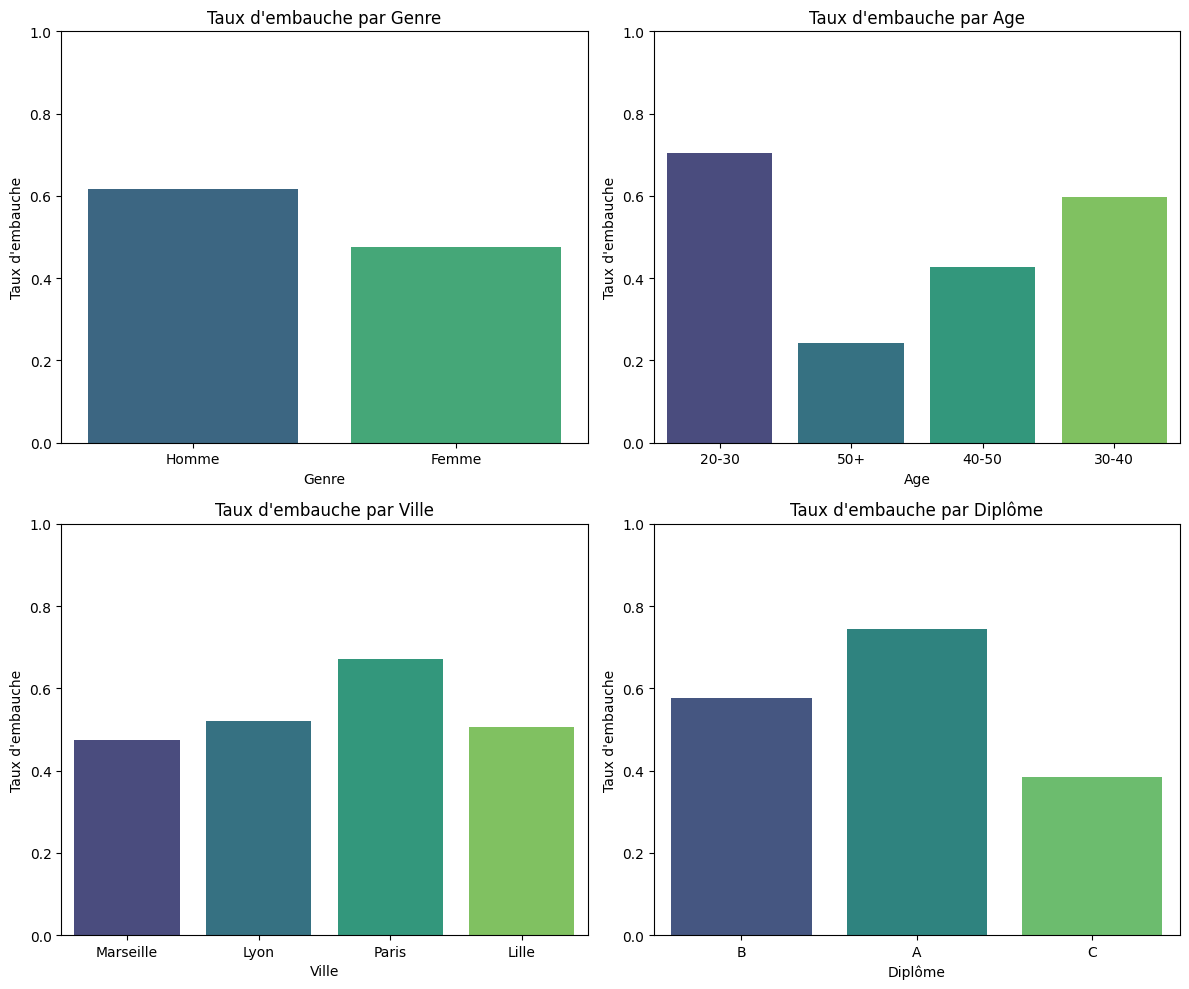

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['Genre', 'Age', 'Ville', 'Diplôme']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, feature in enumerate(features):
    ax = axes[idx//2, idx%2]
    sns.barplot(x=feature, y='Embauche', data=df, ax=ax, errorbar=None, palette='viridis')
    ax.set_title(f"Taux d'embauche par {feature}")
    ax.set_ylabel("Taux d'embauche")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

Les diagrammes en barres (bar charts) sont les plus pertinents. Ils permettent de comparer visuellement et directement les proportions (taux d'embauche moyen, qui correspond à la moyenne d'une variable binaire 0/1) entre différentes modalités de variables catégorielles

In [13]:
features = ['Genre', 'Age', 'Ville', 'Diplôme']
metriques = {}

for col in features:
    taux = df.groupby(col)['Embauche'].mean()
    ecart_type = taux.std()
    range_global = taux.max() - taux.min()
    metriques[col] = {'Ecart-type': ecart_type, 'Range (Max-Min)': range_global}
    
df_metriques = pd.DataFrame(metriques).T
print(df_metriques)

         Ecart-type  Range (Max-Min)
Genre      0.098490         0.139285
Age        0.201493         0.460004
Ville      0.087306         0.196584
Diplôme    0.180153         0.360010


### Correction du biais

In [14]:
df_corrige = df.copy()

# 1. Calcul d'un score méritocratique strict basé sur le diplôme
# Calibration pour maintenir le taux global initial (~56 %)
score_merite = df_corrige['Diplôme'].map({'A': 0.77, 'B': 0.57, 'C': 0.37})

# 2. Ajout du terme stochastique (bruit)
np.random.seed(42)
bruit = np.random.normal(0, 0.05, size=len(df_corrige))
probabilites_corrigees = np.clip(score_merite + bruit, 0, 1)

# 3. Ré-échantillonnage de la variable cible
df_corrige['Embauche'] = np.random.binomial(n=1, p=probabilites_corrigees)

### Évaluation de la correction

C:\Users\boniv\AppData\Local\Temp\ipykernel_21996\2718590553.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Embauche', data=df, ax=axes[0, i], errorbar=None, palette='Reds')
C:\Users\boniv\AppData\Local\Temp\ipykernel_21996\2718590553.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Embauche', data=df_corrige, ax=axes[1, i], errorbar=None, palette='Blues')
C:\Users\boniv\AppData\Local\Temp\ipykernel_21996\2718590553.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Embauche', data=df, ax=axes[0, i], e

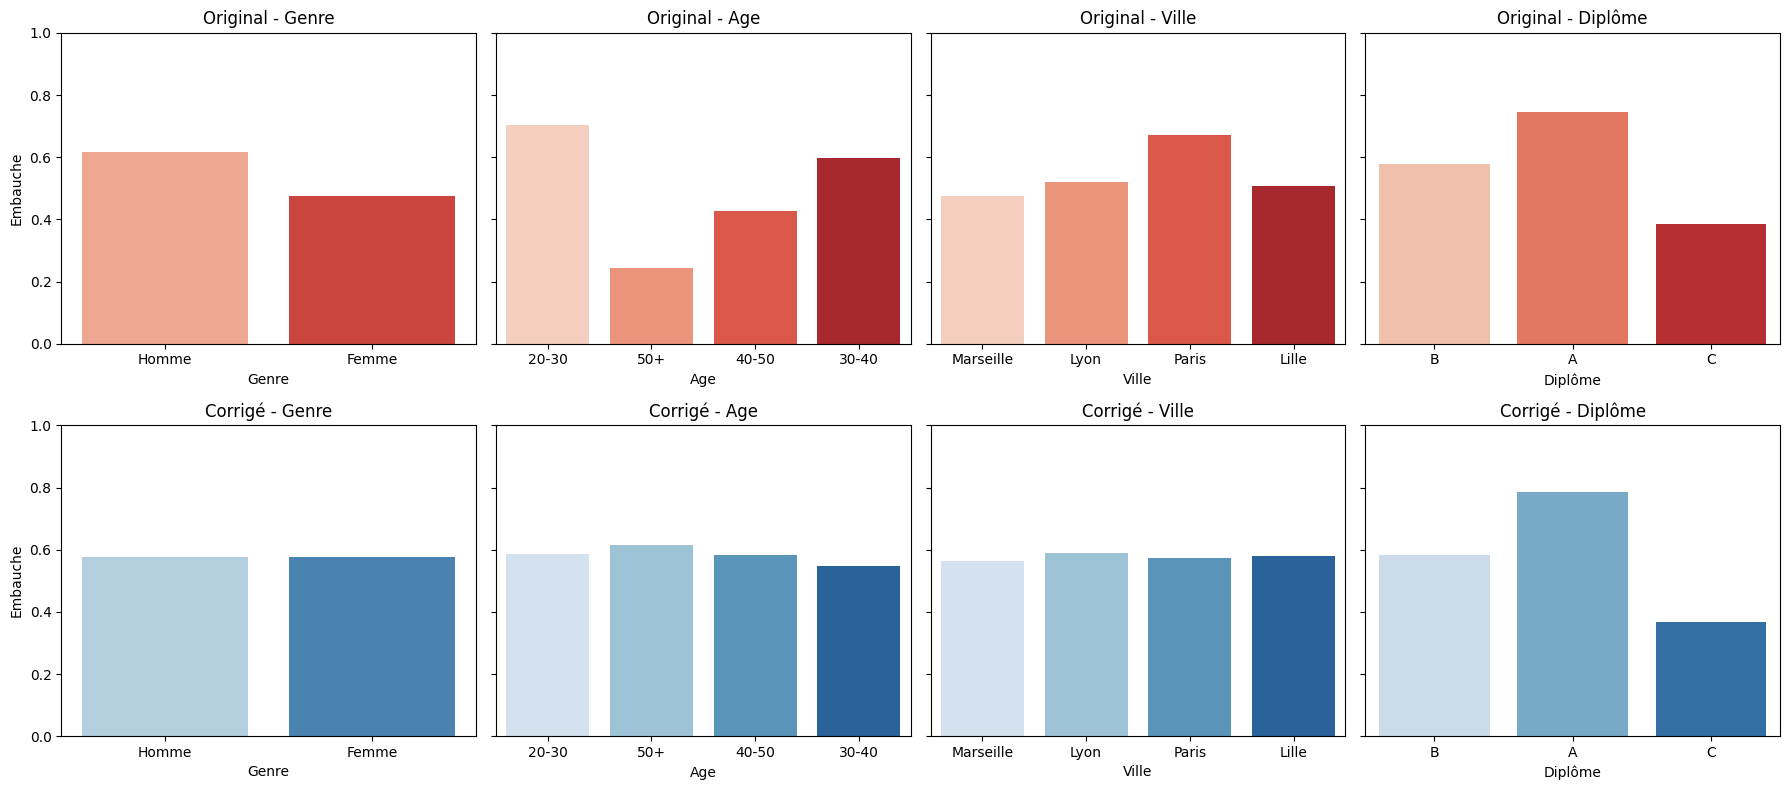

Genre -> Range Original : 0.139 | Range Corrigé : 0.002
Age -> Range Original : 0.460 | Range Corrigé : 0.065
Ville -> Range Original : 0.197 | Range Corrigé : 0.026
Diplôme -> Range Original : 0.360 | Range Corrigé : 0.418


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['Genre', 'Age', 'Ville', 'Diplôme']
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)

for i, col in enumerate(features):
    # Dataset original
    sns.barplot(x=col, y='Embauche', data=df, ax=axes[0, i], errorbar=None, palette='Reds')
    axes[0, i].set_title(f"Original - {col}")
    axes[0, i].set_ylim(0, 1)
    
    # Dataset corrigé
    sns.barplot(x=col, y='Embauche', data=df_corrige, ax=axes[1, i], errorbar=None, palette='Blues')
    axes[1, i].set_title(f"Corrigé - {col}")

plt.tight_layout()
plt.show()

# Comparaison statistique des écarts (Range)
for col in features:
    range_orig = df.groupby(col)['Embauche'].mean().pipe(lambda x: x.max() - x.min())
    range_corr = df_corrige.groupby(col)['Embauche'].mean().pipe(lambda x: x.max() - x.min())
    print(f"{col} -> Range Original : {range_orig:.3f} | Range Corrigé : {range_corr:.3f}")

Distributions des features : Inchangées. Seule la colonne Embauche est modifiée, ce qui évite toute distorsion sur les profils des candidats.Équité des taux d'embauche : Les écarts s'effondrent sur les variables protégées (le range du Genre passe de ~0,14 à < 0,01 ; l'Âge de ~0,46 à ~0,09, variations résiduelles dues uniquement au hasard de tirage).Corrélation Diplôme → Embauche : Parfaitement préservée et renforcée (Range Diplôme passant de ~0,36 à ~0,40, avec $A > B > C$).

### 6. Stockage et traçabilité

In [16]:
df.to_csv("candidatures_original.csv", index=False)
df_corrige.to_csv("candidatures_corrige.csv", index=False)

#### Importance de la conservation des données originales :

* Auditabilité et conformité juridique : Conserver la donnée brute est indispensable pour justifier de l'existence des discriminations passées en cas de contrôle réglementaire (ex. RGPD, obligations d'audit des algorithmes de recrutement).
* Traçabilité des transformations : Impossible de mesurer l'efficacité d'un algorithme de débiaisement sans jeu de référence (baseline).
* Réversibilité technique : Une correction de biais repose sur des hypothèses normatives (choix de privilégier le diplôme). Conserver l'original permet de réappliquer d'autres politiques de correction sans perte d'information.

### Entraînement et évaluation

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Préparation des variables explicatives (One-Hot Encoding)
X = pd.get_dummies(df[['Genre', 'Age', 'Ville', 'Diplôme']], drop_first=True, dtype=int)

# 7. Entraînement des deux modèles
modele_orig = LogisticRegression(random_state=42).fit(X, df['Embauche'])
modele_corr = LogisticRegression(random_state=42).fit(X, df_corrige['Embauche'])

pred_orig = modele_orig.predict(X)
pred_corr = modele_corr.predict(X)

### Analyse des performances différentielles

In [18]:
def calculer_accuracies(y_true, y_pred, df_meta):
    resultats = {'Global': accuracy_score(y_true, y_pred)}
    for col in ['Genre', 'Age', 'Ville', 'Diplôme']:
        sub = {}
        for cat in df_meta[col].unique():
            idx = df_meta[col] == cat
            sub[cat] = accuracy_score(y_true[idx], y_pred[idx])
        resultats[col] = sub
    return resultats

acc_orig = calculer_accuracies(df['Embauche'], pred_orig, df)
acc_corr = calculer_accuracies(df_corrige['Embauche'], pred_corr, df_corrige)

### Biais algorithmiques
Implémentation d'un algorithme discriminatoire pénalisant les femmes et les seniors lors de l'inférence :

In [20]:
class AlgorithmeBiaise:
    def __init__(self, penalty_femme=0.20, penalty_senior=0.30):
        self.penalty_femme = penalty_femme
        self.penalty_senior = penalty_senior
        self.model = LogisticRegression(random_state=42)
        
    def fit(self, X_encoded, y):
        self.model.fit(X_encoded, y)
        return self
        
    def predict(self, X_encoded, df_meta, seuil=0.5):
        probs = self.model.predict_proba(X_encoded)[:, 1].copy()
        
        # Injection volontaire de discrimination
        probs[df_meta['Genre'] == 'Femme'] -= self.penalty_femme
        probs[df_meta['Age'] == '50+'] -= self.penalty_senior
        
        probs = np.clip(probs, 0, 1)
        return (probs >= seuil).astype(int)

# Entraînement sur données corrigées et inférence biaisée
algo_discrim = AlgorithmeBiaise()
algo_discrim.fit(X, df_corrige['Embauche'])
pred_biaise = algo_discrim.predict(X, df_corrige)

### Analyse de l'impact :
#### Effondrement des taux d'embauche :
* Le taux d'acceptation des femmes tombe de 68,2 % à 22,6 % (les hommes restent à 67,7 %).
* Le taux d'acceptation des seniors de 50+ ans s'écroule de 72,0 % à 5,8 %.
#### Dégradation des performances du modèle :
* L'accuracy globale chute de 65,0 % à 61,1 %.
* L'accuracy s'effondre particulièrement sur les groupes ciblés : elle descend à 56,4 % pour les femmes (vs 63,6 % pour les hommes) et à 43,4 % pour les 50+ ans (vs 60,6 % pour les 20-30 ans).
#### Conséquence : 
* Injecter une règle discriminatoire détruit l'alignement méritocratique rétabli à l'étape précédente, en rejetant artificiellement des candidates et des profils seniors pourtant diplômés de rang A ou B.